In [1]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

In [2]:
USE_COLS = [0, 1, 2, 3]

In [3]:
folders = ['2014/2014Q3', '2014/2014Q4', '2015/2015Q1', '2015/2015Q2', '2015/2015Q3', '2015/2015Q4', '2016/2016Q1', '2016/2016Q2', '2016/2016Q3', '2016/2016Q4', '2017/2017Q1', '2017/2017Q2', '2017/2017Q3']
files = []
for f in folders:
    temp = f"Data Files/{f}/performance*.txt"
    file = glob.glob(temp)
    files.extend(os.path.normpath(f) for f in file)
print("Files Found:", len(files))

Files Found: 13


In [4]:
chunksize = 2000000

In [5]:
from collections import defaultdict

transition_counts = defaultdict(int)
transition_balances = defaultdict(float)

In [6]:
def map_bucket(x):
    try:
        x = int(x)
    except:
        return 5  # REO, XX, blanks

    if x == 0:
        return 0
    elif x == 1:
        return 1
    elif x == 2:
        return 2
    elif x == 3:
        return 3
    else:
        return 4

In [7]:
for file in files:
    print("Processing:", file)
    reader = pd.read_csv(file, sep="|", header=None, usecols=USE_COLS, chunksize=chunksize, 
                         dtype={0: "string",
                                1: "string",
                                2: "float32",
                                3: "string"})
    previous_chunk_tail = None
    for chunk in reader:
        chunk.columns = ["loan_id", "reporting_period", "upb", "delq"]
        
        # Convert date
        chunk["reporting_period"] = pd.to_datetime(chunk["reporting_period"],format="%Y%m")

        # Map buckets
        chunk["bucket"] = chunk["delq"].apply(map_bucket)

        if previous_chunk_tail is not None:
            chunk = pd.concat([previous_chunk_tail, chunk], ignore_index=True)

        # Sort inside chunk
        chunk = chunk.sort_values(["loan_id", "reporting_period"])

        last_loan_id = chunk.iloc[-1]["loan_id"]
        mask = chunk["loan_id"] == last_loan_id
        previous_chunk_tail = chunk[mask].copy()
        chunk = chunk[~mask].copy()

        # Create transitions
        chunk["next_bucket"] = (chunk.groupby("loan_id")["bucket"].shift(-1))
        chunk["prev_bucket"] = (chunk.groupby("loan_id")["bucket"].shift(1))
        chunk = chunk.dropna(subset=["prev_bucket","next_bucket"])

        # Aggregate immediately
        count_group = chunk.groupby(["reporting_period","bucket","next_bucket"]).size()
        balance_group = chunk.groupby(["reporting_period","bucket","next_bucket"])["upb"].sum()

        for idx, val in count_group.items():
            transition_counts[idx] += val

        for idx, val in balance_group.items():
            transition_balances[idx] += float(val)

Processing: Data Files\2014\2014Q3\performance_2014Q3.txt
Processing: Data Files\2014\2014Q4\performance_2014Q4.txt
Processing: Data Files\2015\2015Q1\performance_2015Q1.txt
Processing: Data Files\2015\2015Q2\performance_2015Q2.txt
Processing: Data Files\2015\2015Q3\performance_2015Q3.txt
Processing: Data Files\2015\2015Q4\performance_2015Q4.txt
Processing: Data Files\2016\2016Q1\performance_2016Q1.txt
Processing: Data Files\2016\2016Q2\performance_2016Q2.txt
Processing: Data Files\2016\2016Q3\performance_2016Q3.txt
Processing: Data Files\2016\2016Q4\performance_2016Q4.txt
Processing: Data Files\2017\2017Q1\performance_2017Q1.txt
Processing: Data Files\2017\2017Q2\performance_2017Q2.txt
Processing: Data Files\2017\2017Q3\performance_2017Q3.txt


In [8]:
count_df = pd.Series(transition_counts).reset_index()
count_df.columns = ["reporting_period", "bucket", "next_bucket", "count"]

balance_df = pd.Series(transition_balances).reset_index()
balance_df.columns = ["reporting_period", "bucket", "next_bucket", "balance"]

roll_counts = count_df.merge(balance_df, on=["reporting_period","bucket","next_bucket"])

In [9]:
print(f'Data Shape before dropping future data:', roll_counts.shape)

Data Shape before dropping future data: (3498, 5)


In [10]:
mask_time = (roll_counts['reporting_period'] >= '2014-07-01') & (roll_counts['reporting_period'] <= '2017-09-30')
roll_counts = roll_counts[mask_time].copy()

In [11]:
print(f'Data Shape after dropping future data:', roll_counts.shape)

Data Shape after dropping future data: (909, 5)


In [12]:
roll_counts["count_roll_rate"] = (roll_counts["count"] / roll_counts.groupby(["reporting_period","bucket"])["count"].transform("sum"))
roll_counts["balance_roll_rate"] = (roll_counts["balance"] / roll_counts.groupby(["reporting_period","bucket"])["balance"].transform("sum"))

In [13]:
rr12_data = roll_counts[(roll_counts['bucket'] == 1) & (roll_counts['next_bucket'] == 2)].copy()
rr12_data = rr12_data.sort_values('reporting_period').set_index('reporting_period')
y = rr12_data['count_roll_rate']

In [14]:
# Train: 2014 Q3 through 2017 Q2
# Test: 2017 Q3
train = y.loc[:'2017-06-30']
test = y.loc['2017-07-01':'2017-09-30']

In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

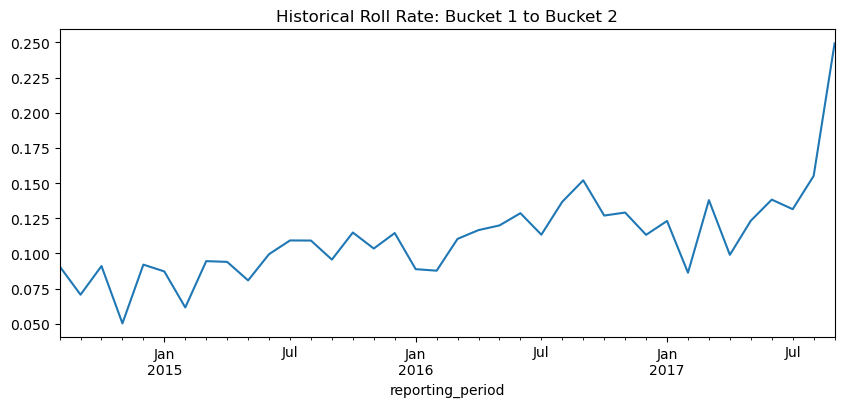

In [16]:
y.plot(title='Historical Roll Rate: Bucket 1 to Bucket 2', figsize=(10, 4))
plt.show()

In [17]:
# Augmented Dickey-Fuller (ADF) Test to test the training data for stationarity
print("\n--- Augmented Dickey-Fuller Test ---")
adf_result = adfuller(train.dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

# Differencing logic (if needed)
if adf_result[1] > 0.05:
    print("Data is non-stationary. Differencing is required (d > 0).")
    train_diff = train.diff().dropna()
else:
    print("Data is stationary. No differencing required (d = 0).")
    train_diff = train # Keep original


--- Augmented Dickey-Fuller Test ---
ADF Statistic: -1.6510
p-value: 0.4565
Data is non-stationary. Differencing is required (d > 0).


Generating ACF and PACF plots on the differenced training data


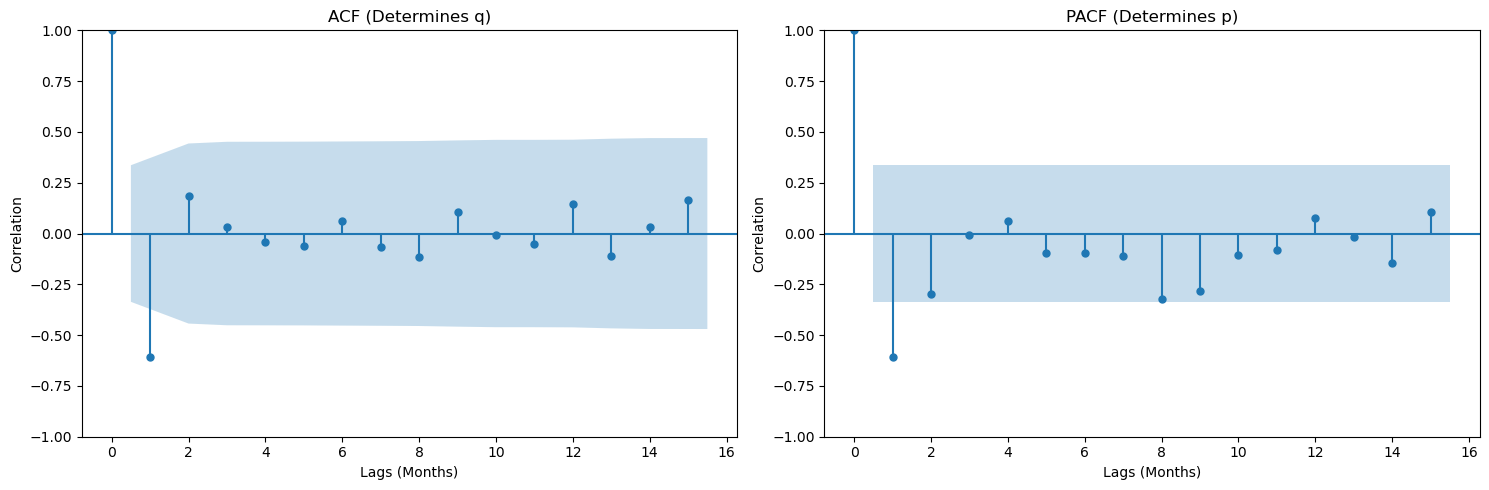

In [18]:
print("Generating ACF and PACF plots on the differenced training data")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(train_diff, ax=axes[0], lags=15, title='ACF (Determines q)')
axes[0].set_xlabel('Lags (Months)')
axes[0].set_ylabel('Correlation')

plot_pacf(train_diff, ax=axes[1], lags=15, title='PACF (Determines p)', method='ywm')
axes[1].set_xlabel('Lags (Months)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [20]:
model1 = ARIMA(train, order=(1, 1, 1))
fitted_model1 = model1.fit()

print(f"Model AIC Score: {fitted_model1.aic:.2f}")

Model AIC Score: -174.28


E:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
E:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:
print("Generating Forecast for 2017 Q3")
predictions = fitted_model1.forecast(steps=len(test))
predictions.index = test.index

Generating Forecast for 2017 Q3


In [22]:
from sklearn.metrics import mean_absolute_percentage_error
rmse = np.sqrt(mean_squared_error(test, predictions))*100
mae = mean_absolute_error(test, predictions)*100
mape = mean_absolute_percentage_error(test, predictions)*100

print("--- FINAL BASELINE EVALUATION METRICS ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}%")
print(f"Mean Absolute Error (MAE):      {mae:.6f}%")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.6f}%")

--- FINAL BASELINE EVALUATION METRICS ---
Root Mean Squared Error (RMSE): 7.349886%
Mean Absolute Error (MAE):      5.374957%
Mean Absolute Percentage Error (MAPE): 24.973007%


In [ ]:
def log_quarterly_metrics(quarter, metrics_list, output_file="roll_rate_results.csv"):
    df_quarter = pd.DataFrame(metrics_list)
    df_quarter.insert(0, 'quarter', quarter)
    file_exists = os.path.isfile(output_file)
    df_quarter.to_csv(output_file, mode='a', header=not file_exists, index=False)

In [ ]:
current_test_quarter = "2017Q3"
quarter_metrics = []
actual = test.mean()
predicted = predictions.mean()
t_rmse = rmse
t_mae = mae
t_mape = mape
quarter_metrics.append({'actual_rr': actual, 'pred_rr': predicted, 'rmse': t_rmse, 'mae': t_mae, 'mape': t_mape})

log_quarterly_metrics(current_test_quarter, quarter_metrics)